# Internet Quality Checker

This notebook uses the `internet_quality_checker` package modules for Google Meet-oriented connection monitoring.

Core code is split into:

- `config.py`: thresholds and probe defaults
- `network.py`: Wi-Fi helpers, TCP latency probes, speed probes, monitor runner
- `metrics.py`: jitter, packet loss, summaries, quality status
- `plotting.py`: live dashboard plots
- `reporting.py`: CSV/PDF export
- `comparison.py`: saved-run comparison plots
- `ui.py`: notebook widgets

In [1]:
%pip install -q aiohttp pandas matplotlib ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
from internet_quality_checker.comparison import display_meet_connection_comparison
from internet_quality_checker.reporting import export_all_results
from internet_quality_checker.ui import (
    create_network_control_widgets,
    export_label_from_widget,
    start_monitor_from_widgets,
)

## Choose Network Name and Controls

Enter the label that should be used in charts, summaries, and exported filenames. Click **Use this network name** to confirm what the notebook read. Click **Stop monitor** while a test is running to stop cleanly and save the automatic CSV.

In [5]:
network_controls = create_network_control_widgets(default="Peanut Butter")
network_name_widget = network_controls["network_name"]
stop_signal = network_controls["stop_signal"]

## Run Sequential Test

Connect to the network, set and confirm the widget label above, then run this cell. It starts the monitor in the background so the notebook stays responsive. Use the **Stop monitor** button to stop early and save the automatic CSV.

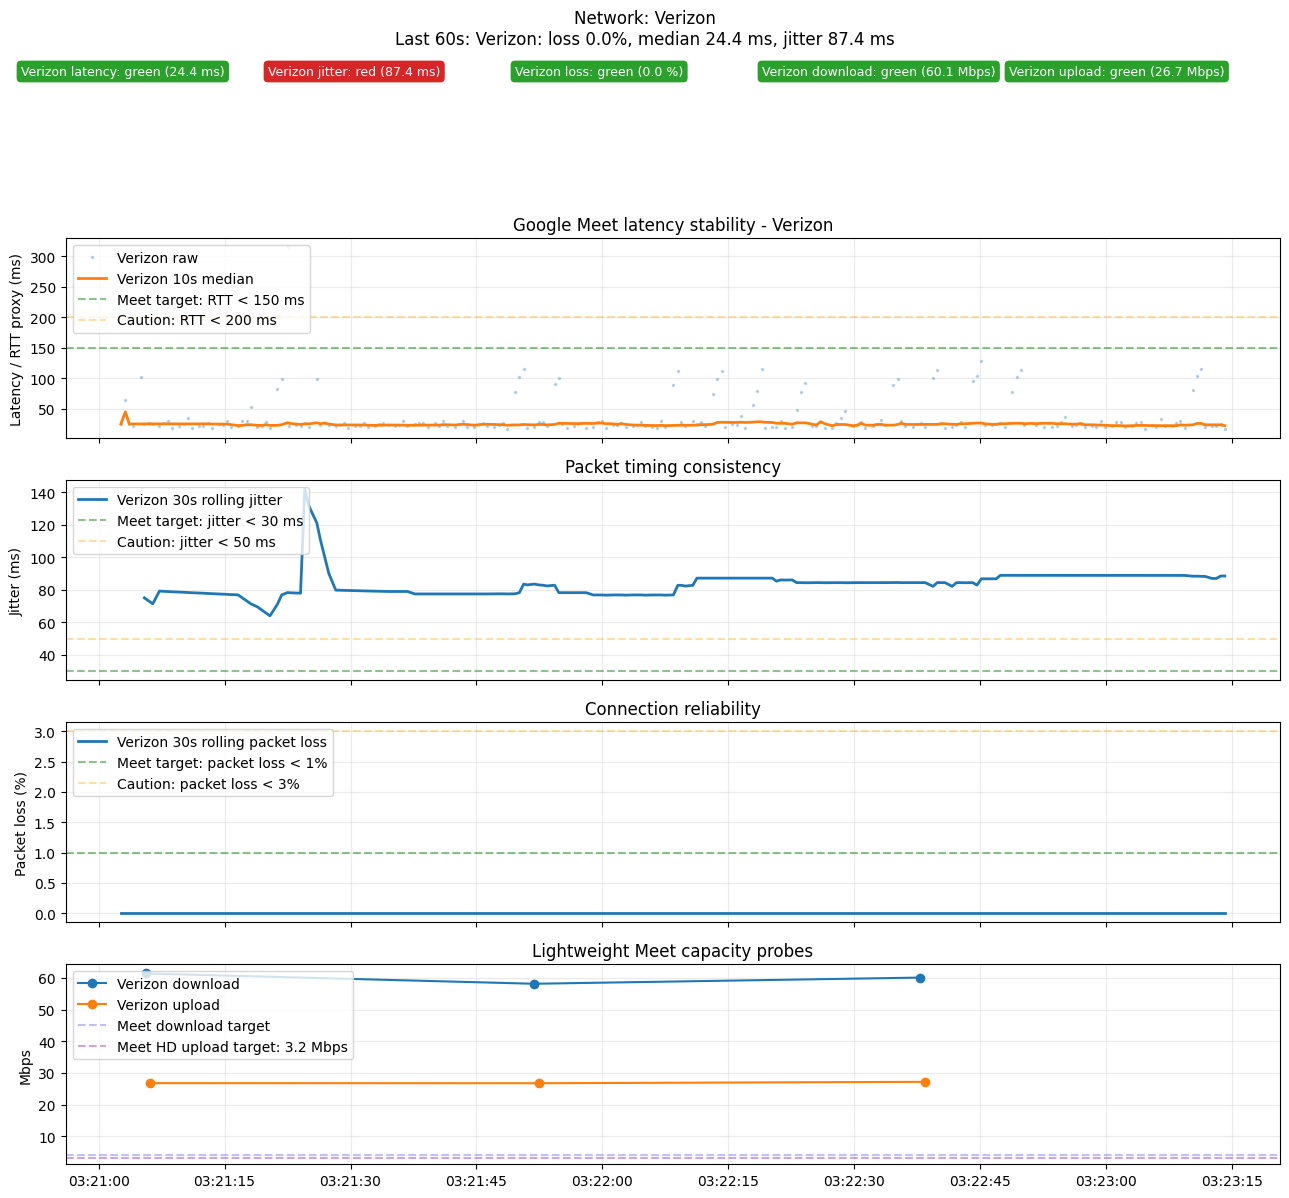

In [ ]:
monitor_task = start_monitor_from_widgets(
    network_name_widget,
    stop_signal,
    duration_seconds=300,
)
monitor_task

## Export After Stopping

Run this after the monitor finishes or after you interrupt it.

In [ ]:
export_label = export_label_from_widget(network_name_widget)
csv_path, pdf_path = export_all_results(label=export_label)
print("CSV:", csv_path)
print("PDF:", pdf_path)

## Compare Saved Runs

This loads the latest `*_raw_*.csv` per network label from `internet_quality_results/` and compares their distributions.

In [ ]:
comparison_results = display_meet_connection_comparison()